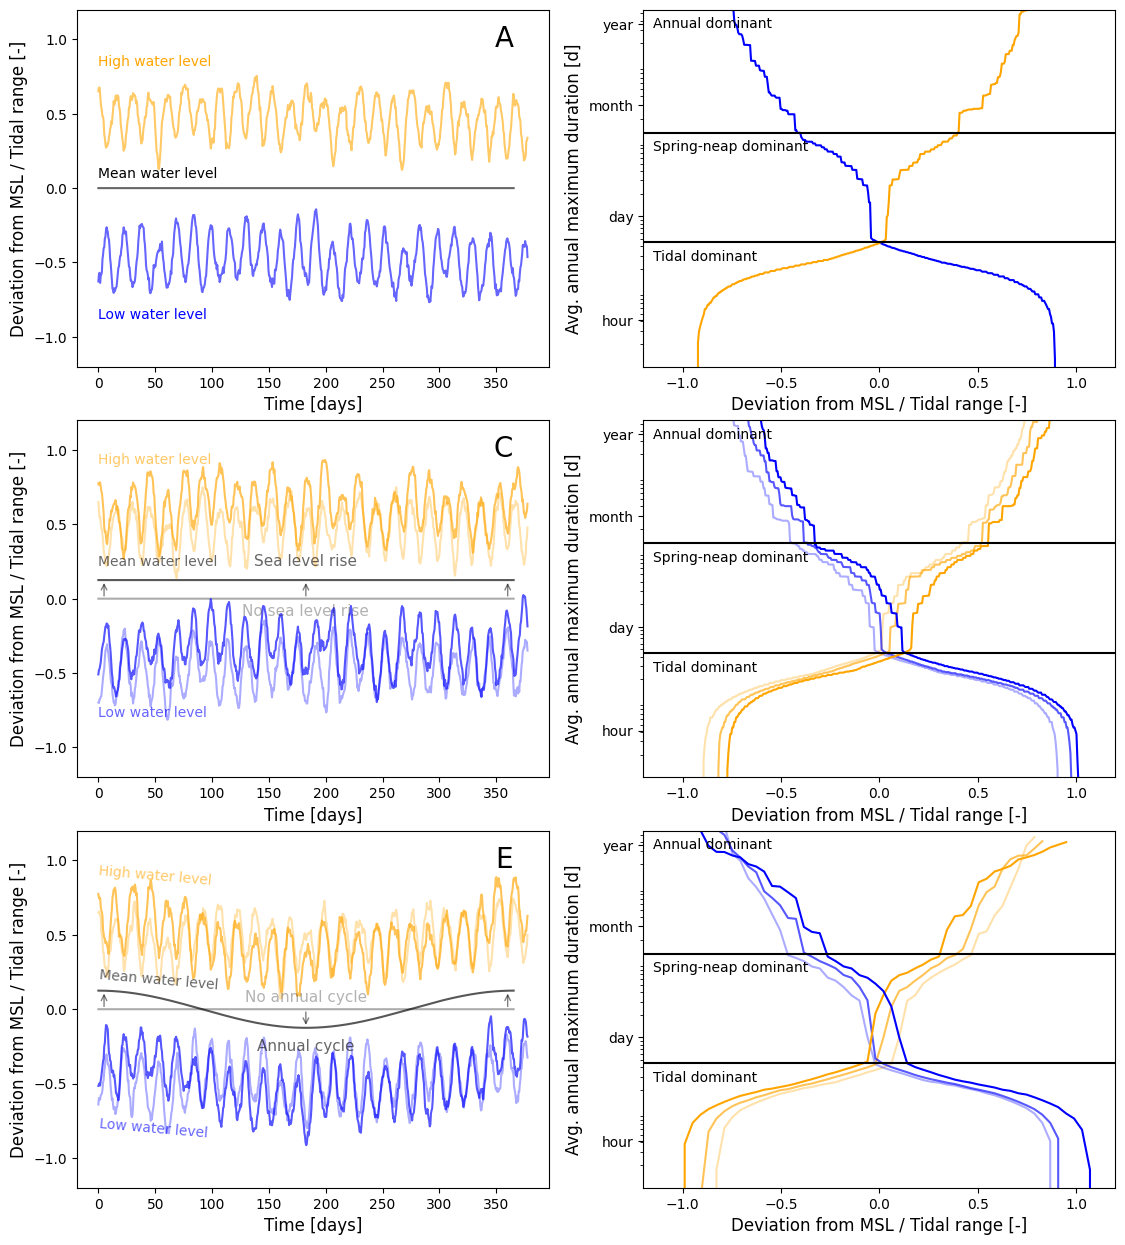

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import os

# path_root = "/Users/timhermans/Documents/GitHub/aslc_intertidal"
path_root = "F:/collaborations/Tim_Hermans/aslc_intertidal"
os.chdir(path_root)

import src.functions as f

def figure_1a(ax):

    time, waterlevel, mean_waterlevel = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0., mean_waterlevel = 0., n_years = 1)

    tidal_cycle, low_waterlevel, high_waterlevel = f.calculate_highlow_water(waterlevel, plot = False)        
    ax.plot(time/24, mean_waterlevel, zorder = 1, c = 'black', alpha = 0.6)
    ax.plot(365*tidal_cycle/705, low_waterlevel, c = 'blue', alpha = 0.6)
    ax.plot(365*tidal_cycle/705, high_waterlevel, c = 'orange', alpha = 0.6)

    ax.text(x = 0,     y =  0.85, s = 'High water level',  c = 'orange', fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = 0)
    ax.text(x = 0,     y =  0.1, s = 'Mean water level',  c = 'black',  fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = 0)
    ax.text(x = 0,     y = -0.85, s = 'Low water level',   c = 'blue',   fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = 0)
    ax.text(x = 365, y = 1.1, s = 'A',  c = 'black',  fontsize = 20, horizontalalignment = 'right',   verticalalignment = 'top', rotation = 0)

    ax.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax.set_xlabel('Time [days]', fontsize = 12)
    ax.set_ylim(-1.2, 1.2)

def figure_1b(ax, path_bin = './bin/supp_note_3/figure_1/figure_1b.npy'):

    if not os.path.exists(path_bin):
        dt = 5/60
        _, waterlevel, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0. , n_years = 100, dt = dt)
        elevation = np.arange(waterlevel.min(), waterlevel.max() + 0.005, 0.005)
        avg_max_inundation_duration, avg_max_emergent_duration = f.find_avg_max_duration(elevation, waterlevel, dt)
        np.save(path_bin, [elevation, avg_max_inundation_duration, avg_max_emergent_duration])
    else:
        elevation, avg_max_inundation_duration, avg_max_emergent_duration = np.load(path_bin)
    
    ax.plot(elevation, avg_max_inundation_duration, c = 'blue', alpha = 1)
    ax.plot(elevation, avg_max_emergent_duration, c = 'orange', alpha = 1)
    ax.plot([-2.4, 2.4], [0.45,0.45], c = 'black')
    ax.text(-1.15, 0.45*0.8, s = 'Tidal dominant', c = 'black', verticalalignment = 'top', horizontalalignment = 'left')
    ax.plot([-2.4, 2.4], [13,13], c = 'black')
    ax.text(-1.15, 13*0.8, s = 'Spring-neap dominant ', c = 'black', verticalalignment = 'top', horizontalalignment = 'left')
    ax.text(-1.15, 450, s = 'Annual dominant', c = 'black', verticalalignment = 'top', horizontalalignment = 'left')

    ax.set_yscale('log')
    ax.set_yticks(ticks = [1/24,1,30,365.25], labels = ['hour', 'day', 'month','year'])
    ax.set_ylabel('Avg. annual maximum duration [d]', fontsize = 12)
    ax.set_xlabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax.set_ylim(10**-2,10**2.75)
    ax.set_xlim(-1.2, 1.2)

def figure_1c(ax):

    def closest_to(seq, x):
        return np.argmin(np.abs(x - seq))
    
    time, waterlevel, mean_waterlevel_0 = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0., mean_waterlevel = 0., n_years = 1)        
    tidal_cycle, low_waterlevel_0, high_waterlevel_0 = f.calculate_highlow_water(waterlevel, plot = False)    
    ax.plot(365*tidal_cycle/705, high_waterlevel_0, c = 'orange', alpha = 0.33)
    ax.plot(time/24, mean_waterlevel_0, zorder = 1, c = 'black', alpha = 0.33)
    ax.plot(365*tidal_cycle/705, low_waterlevel_0, c = 'blue', alpha = 0.33)

    time, waterlevel, mean_waterlevel_1 = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0., mean_waterlevel = 0.25, n_years = 1)
    tidal_cycle, low_waterlevel_1, high_waterlevel_1 = f.calculate_highlow_water(waterlevel, plot = False)
    ax.plot(365*tidal_cycle/705, high_waterlevel_1, c = 'orange', alpha = 0.66, label = 'High water level')
    ax.plot(time/24, mean_waterlevel_1, zorder = 1, c = 'black', alpha = 0.66, label = 'Mean water level')
    ax.plot(365*tidal_cycle/705, low_waterlevel_1, c = 'blue', alpha = 0.66, label = 'Low water level')

    ax.annotate('', 
                xy = (5, mean_waterlevel_1[closest_to(time/24, 5)]), 
                xytext = (5, mean_waterlevel_0[closest_to(time/24, 5)]),
                arrowprops=dict(arrowstyle='->', color='black', lw = 1, alpha = 0.5))

    ax.annotate('', 
                xy = (365/2, mean_waterlevel_1[closest_to(time/24, 365/2)]), 
                xytext = (365/2, mean_waterlevel_0[closest_to(time/24, 365/2)]),
                arrowprops=dict(arrowstyle='->', color='black', lw = 1, alpha = 0.5))

    ax.annotate('', 
                xy = (360, mean_waterlevel_1[closest_to(time/24, 360)]), 
                xytext = (360, mean_waterlevel_0[closest_to(time/24, 360)]),
                arrowprops=dict(arrowstyle='->', color='black', lw = 1, alpha = 0.5))

    ax.text(x = 365/2, y = -0.166/2, s = 'No sea level rise', c = 'black',  alpha = 0.3, fontsize = 11, horizontalalignment = 'center', verticalalignment = 'center')
    ax.text(x = 365/2, y =  0.500/2, s = 'Sea level rise',    c = 'black',  alpha = 0.6, fontsize = 11, horizontalalignment = 'center', verticalalignment = 'center')
    ax.text(x = 0,     y =  1.866/2, s = 'High water level',  c = 'orange', alpha = 0.6, fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = 0)
    ax.text(x = 0,     y =  0.500/2, s = 'Mean water level',  c = 'black',  alpha = 0.6, fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = 0)
    ax.text(x = 0,     y = -1.533/2, s = 'Low water level',   c = 'blue',   alpha = 0.6, fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = 0)
    ax.text(x = 365, y = 1.1, s = 'C',  c = 'black',  fontsize = 20, horizontalalignment = 'right',   verticalalignment = 'top', rotation = 0)

    ax.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax.set_xlabel('Time [days]', fontsize = 12)
    ax.set_ylim(-2.4/2, 2.4/2)

def figure_1d(ax, path_bin_0 = './bin/supp_note_3/figure_1/figure_1c-0.npy', path_bin_1 = './bin/supp_note_3/figure_1/figure_1c-1.npy', path_bin_2 = './bin/supp_note_3/figure_1/figure_1c-2.npy'):

    # Run tidal water level scenarios
    if not os.path.exists(path_bin_0):
        dt = 5/60
        _, waterlevel, _ = f.create_waterlevel_timeseries(mean_waterlevel = 0., n_years = 100, dt = dt)
        elevation_0 = np.arange(waterlevel.min(), waterlevel.max() + 0.005, 0.005)
        avg_max_inundation_duration_0, avg_max_emergent_duration_0 = f.find_avg_max_duration(elevation_0, waterlevel, dt)
        np.save(path_bin_0, [elevation_0, avg_max_inundation_duration_0, avg_max_emergent_duration_0])
    else:
        elevation_0, avg_max_inundation_duration_0, avg_max_emergent_duration_0 = np.load(path_bin_0)

    if not os.path.exists(path_bin_1):
        dt = 5/60
        _, waterlevel, _ = f.create_waterlevel_timeseries(mean_waterlevel = 0.125, n_years = 100, dt = dt)
        elevation_1 = np.arange(waterlevel.min(), waterlevel.max() + 0.005, 0.005)
        avg_max_inundation_duration_1, avg_max_emergent_duration_1 = f.find_avg_max_duration(elevation_1, waterlevel, dt)
        np.save(path_bin_1, [elevation_1, avg_max_inundation_duration_1, avg_max_emergent_duration_1])
    else:
        elevation_1, avg_max_inundation_duration_1, avg_max_emergent_duration_1 = np.load(path_bin_1)

    if not os.path.exists(path_bin_2):
        dt = 5/60
        _, waterlevel, _ = f.create_waterlevel_timeseries(mean_waterlevel = 0.25, n_years = 100, dt = dt)
        elevation_2 = np.arange(waterlevel.min(), waterlevel.max() + 0.005, 0.005)
        avg_max_inundation_duration_2, avg_max_emergent_duration_2 = f.find_avg_max_duration(elevation_2, waterlevel, dt)
        np.save(path_bin_2, [elevation_2, avg_max_inundation_duration_2, avg_max_emergent_duration_2])
    else:
        elevation_2, avg_max_inundation_duration_2, avg_max_emergent_duration_2 = np.load(path_bin_2)

    # Draw emergence/inundation frequency curves
    ax.plot(elevation_0, avg_max_emergent_duration_0, c = 'orange', alpha = 0.33)
    ax.plot(elevation_0, avg_max_inundation_duration_0, c = 'blue', alpha = 0.33)
    ax.plot(elevation_1, avg_max_emergent_duration_1, c = 'orange', alpha = 0.66)
    ax.plot(elevation_1, avg_max_inundation_duration_1, c = 'blue', alpha = 0.66)
    ax.plot(elevation_2, avg_max_emergent_duration_2, label = 'Emergence', c = 'orange', alpha = 1)
    ax.plot(elevation_2, avg_max_inundation_duration_2, label = 'Inundation', c = 'blue', alpha = 1)

    ax.plot([-2.4, 2.4], [0.45,0.45], c = 'black')
    ax.text(-1.15, 0.45*0.8, s = 'Tidal dominant', c = 'black', verticalalignment = 'top', horizontalalignment = 'left')
    ax.plot([-2.4, 2.4], [13,13], c = 'black')
    ax.text(-1.15, 13*0.8, s = 'Spring-neap dominant ', c = 'black', verticalalignment = 'top', horizontalalignment = 'left')
    ax.text(-1.15, 450, s = 'Annual dominant', c = 'black', verticalalignment = 'top', horizontalalignment = 'left')

    ax.set_yscale('log')
    ax.set_yticks(ticks = [1/24,1,30,365.25], labels = ['hour', 'day', 'month','year'])
    ax.set_ylabel('Avg. annual maximum duration [d]', fontsize = 12)
    ax.set_xlabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax.set_ylim(10**-2,10**2.75)
    ax.set_xlim(-1.2, 1.2)

def figure_1e(ax):

    def closest_to(seq, x):
        return np.argmin(np.abs(x - seq))
    
    time, waterlevel, mean_waterlevel = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0., mean_waterlevel = 0., n_years = 1)
    tidal_cycle, low_waterlevel, high_waterlevel = f.calculate_highlow_water(waterlevel, plot = False)        
    ax.plot(time/24, mean_waterlevel, zorder = 1, c = 'black', alpha = 0.33)
    ax.plot(365*tidal_cycle/705, low_waterlevel, c = 'blue', alpha = 0.33)
    ax.plot(365*tidal_cycle/705, high_waterlevel, c = 'orange', alpha = 0.33)

    time, waterlevel, mean_waterlevel = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0.25, mean_waterlevel = 0., n_years = 1)
    tidal_cycle, low_waterlevel, high_waterlevel = f.calculate_highlow_water(waterlevel, plot = False)
    ax.plot(365*tidal_cycle/705, high_waterlevel, c = 'orange', alpha = 0.66, label = 'High water level')
    ax.plot(time/24, mean_waterlevel, zorder = 1, c = 'black', alpha = 0.66, label = 'Mean water level')
    ax.plot(365*tidal_cycle/705, low_waterlevel, c = 'blue', alpha = 0.66, label = 'Low water level')

    ax.annotate('', 
                xy = (365/2, mean_waterlevel[closest_to(time/24, 365/2)]), 
                xytext = (365/2, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw = 1, alpha = 0.5))

    ax.annotate('', 
                xy = (5, mean_waterlevel[closest_to(time/24, 5)]), 
                xytext = (5, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw = 1, alpha = 0.5))

    ax.annotate('', 
                xy = (360, mean_waterlevel[closest_to(time/24, 360)]), 
                xytext = (360, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw = 1, alpha = 0.5))

    ax.text(x = 365/2, y =  0.166/2, s = 'No annual cycle',  c = 'black',  alpha = 0.3, fontsize = 11, horizontalalignment = 'center', verticalalignment = 'center')
    ax.text(x = 365/2, y = -0.5/2, s = 'Annual cycle',     c = 'black',  alpha = 0.6, fontsize = 11, horizontalalignment = 'center', verticalalignment = 'center')
    ax.text(x = 0,     y =  1.800/2, s = 'High water level', c = 'orange', alpha = 0.6, fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = -5)
    ax.text(x = 0,     y =  0.4/2, s = 'Mean water level', c = 'black',  alpha = 0.6, fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = -5)
    ax.text(x = 0,     y = -1.599/2, s = 'Low water level',  c = 'blue',   alpha = 0.6, fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = -5)

    ax.text(x = 365, y = 1.1, s = 'E',  c = 'black',  fontsize = 20, horizontalalignment = 'right',   verticalalignment = 'top', rotation = 0)
    ax.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax.set_xlabel('Time [days]', fontsize = 12)
    ax.set_ylim(-2.4/2, 2.4/2)

def figure_1f(ax, path_bin_0 = './bin/supp_note_3/figure_1/figure_1f-0.npy', path_bin_1 = './bin/supp_note_3/figure_1/figure_1f-1.npy', path_bin_2 = './bin/supp_note_3/figure_1/figure_1f-2.npy'):

    dt = 5/60
    nz = 100
    nyears = 10
    elevation = np.linspace(-2, 2, nz)

    # Run tidal water level scenarios
    if not os.path.exists(path_bin_0):
        _, waterlevel, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0., n_years = nyears, dt = dt)
        avg_max_inundation_duration_0, avg_max_emergent_duration_0 = f.find_avg_max_duration(elevation, waterlevel, dt)
        np.save(path_bin_0, [elevation, avg_max_inundation_duration_0, avg_max_emergent_duration_0])
    else:
        elevation, avg_max_inundation_duration_0, avg_max_emergent_duration_0 = np.load(path_bin_0)

    if not os.path.exists(path_bin_1):
        _, waterlevel, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0.225, n_years = nyears, dt = dt)
        avg_max_inundation_duration_1, avg_max_emergent_duration_1 = f.find_avg_max_duration(elevation, waterlevel, dt)
        np.save(path_bin_1, [elevation, avg_max_inundation_duration_1, avg_max_emergent_duration_1])
    else:
        elevation, avg_max_inundation_duration_1, avg_max_emergent_duration_1 = np.load(path_bin_1)

    if not os.path.exists(path_bin_2):
        _, waterlevel, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0.45, n_years = nyears, dt = dt)
        avg_max_inundation_duration_2, avg_max_emergent_duration_2 = f.find_avg_max_duration(elevation, waterlevel, dt)
        np.save(path_bin_2, [elevation, avg_max_inundation_duration_2, avg_max_emergent_duration_2])
    else:
        elevation, avg_max_inundation_duration_2, avg_max_emergent_duration_2 = np.load(path_bin_2)

    # Draw emergence/inundation frequency curves
    ax.plot(elevation, avg_max_emergent_duration_0, c = 'orange', alpha = 0.33)
    ax.plot(elevation, avg_max_inundation_duration_0, c = 'blue', alpha = 0.33)
    ax.plot(elevation, avg_max_emergent_duration_1, c = 'orange', alpha = 0.66)
    ax.plot(elevation, avg_max_inundation_duration_1, c = 'blue', alpha = 0.66)
    ax.plot(elevation, avg_max_emergent_duration_2, label = 'Emergence', c = 'orange', alpha = 1)
    ax.plot(elevation, avg_max_inundation_duration_2, label = 'Inundation', c = 'blue', alpha = 1)

    ax.plot([-2.4, 2.4], [0.45,0.45], c = 'black')
    ax.text(-1.15, 0.45*0.8, s = 'Tidal dominant', c = 'black', verticalalignment = 'top', horizontalalignment = 'left')
    ax.plot([-2.4, 2.4], [13,13], c = 'black')
    ax.text(-1.15, 13*0.8, s = 'Spring-neap dominant ', c = 'black', verticalalignment = 'top', horizontalalignment = 'left')
    ax.text(-1.15, 450, s = 'Annual dominant', c = 'black', verticalalignment = 'top', horizontalalignment = 'left')

    ax.set_yscale('log')
    ax.set_yticks(ticks = [1/24,1,30,365.25], labels = ['hour', 'day', 'month','year'])
    ax.set_ylabel('Avg. annual maximum duration [d]', fontsize = 12)
    ax.set_xlabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax.set_ylim(10**-2,10**2.75)
    ax.set_xlim(-1.2, 1.2)

def figure_1_multipanel(path_png = None):

    np.random.seed(12345)

    fig = plt.figure(figsize=((6.4 + 0.3)*2,(4.8 + 0.3)*3))
    gs1 = fig.add_gridspec(3,2,hspace=.15, wspace=.20) #define subplot grid

    ax = fig.add_subplot(gs1[0,0])
    figure_1a(ax)
    ax = fig.add_subplot(gs1[0,1])
    figure_1b(ax)
    ax = fig.add_subplot(gs1[1,0])
    figure_1c(ax)
    ax = fig.add_subplot(gs1[1,1])
    figure_1d(ax)
    ax = fig.add_subplot(gs1[2,0])
    figure_1e(ax)
    ax = fig.add_subplot(gs1[2,1])
    figure_1f(ax) 

    if path_png is not None:
        plt.savefig(path_png, dpi = 300, bbox_inches = "tight", pad_inches = 0.2)
    plt.show()

figure_1_multipanel(path_png = './figures/supp_note_3/inundation_duration_tests/figure_1-alt.png')